Descriptive statistics for closing price:
count    2516.000000
mean      143.385988
std       101.584762
min        29.178000
25%        49.143850
50%       103.314000
75%       237.125000
max       379.099000
Name: close, dtype: float64

Descriptive statistics for daily return:
count    2515.000000
mean        0.001134
std         0.017052
min        -0.147393
25%        -0.006782
50%         0.000867
75%         0.009813
max         0.142173
Name: daily_return, dtype: float64

Standard deviation: 0.017052
Variance: 0.000291
Skewness: 0.1097
Kurtosis: 7.8662

Outlier bounds: -0.0317 to 0.0347
Number of outliers: 131

RQ1: Monthly Return Seasonality


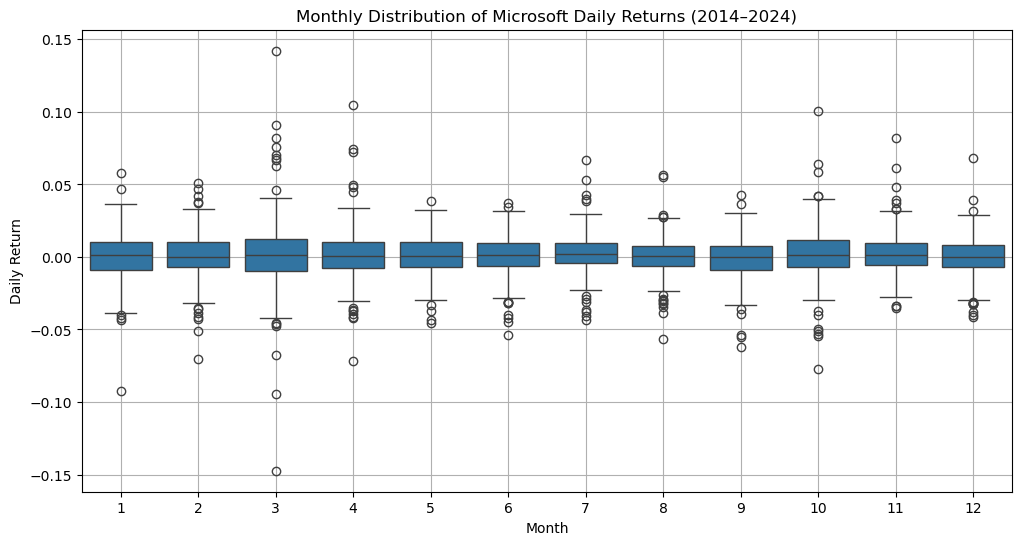

                            OLS Regression Results                            
Dep. Variable:           daily_return   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.9391
Date:                Sun, 08 Jun 2025   Prob (F-statistic):              0.501
Time:                        22:35:19   Log-Likelihood:                 6070.3
No. Observations:                2307   AIC:                        -1.212e+04
Df Residuals:                    2295   BIC:                        -1.205e+04
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          0.0007      0.001      0.

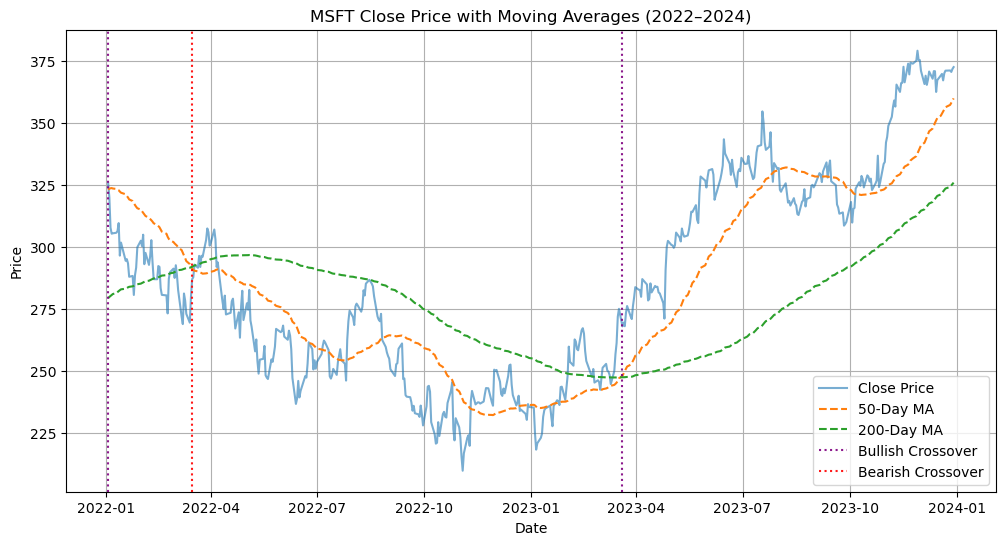


RQ2 Extended: Multi-Day Return Evaluation After MA Crossovers

* RETURN_3D Comparison
  Bullish Mean: 0.0197, Bearish Mean: 0.0120
  t-statistic: 0.5155, p-value: 0.6223
RQ3: No significant difference — crossovers not statistically predictive at this horizon

* RETURN_5D Comparison
  Bullish Mean: 0.0269, Bearish Mean: 0.0139
  t-statistic: 0.9783, p-value: 0.3625
RQ3: No significant difference — crossovers not statistically predictive at this horizon

* RETURN_10D Comparison
  Bullish Mean: 0.0513, Bearish Mean: 0.0558
  t-statistic: -0.2221, p-value: 0.8306
RQ3: No significant difference — crossovers not statistically predictive at this horizon


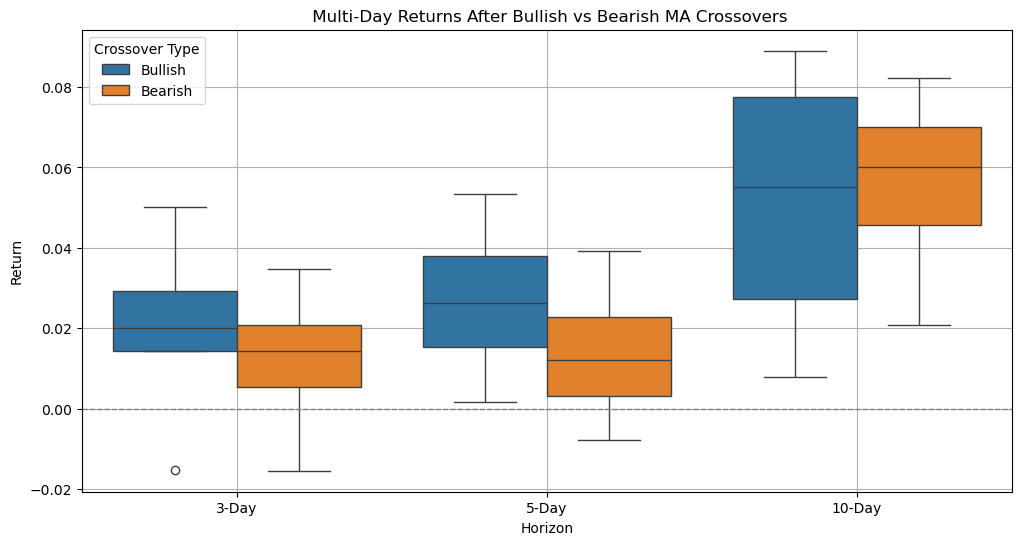


RQ2 Extended: Predictive Modeling of Returns After MA Crossovers

Linear Regression Results (Predicting 5-Day Return)
R² Score: -0.4647
Mean Squared Error: 0.002692

Top Predictive Features (Linear Regression):
volatility_20d    1.969305
daily_return      0.578463
macd              0.011469
rsi              -0.000626
signal_line      -0.007099
volatility_5d    -1.063472
dtype: float64


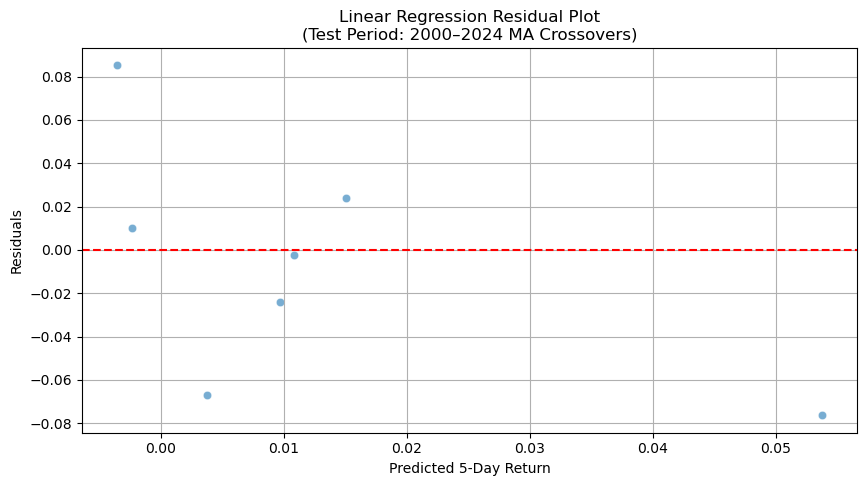


Logistic Regression Results (Classify 5-Day Return > 0)
Accuracy: 0.4286
ROC-AUC: 0.1667

Classification Report:
              precision    recall  f1-score   support

    Negative       0.00      0.00      0.00         3
    Positive       0.50      0.75      0.60         4

    accuracy                           0.43         7
   macro avg       0.25      0.38      0.30         7
weighted avg       0.29      0.43      0.34         7


Top Predictive Features (Logistic Regression):
macd              0.393179
daily_return      0.123811
volatility_5d     0.017618
volatility_20d    0.005418
rsi              -0.039243
signal_line      -0.280037
dtype: float64


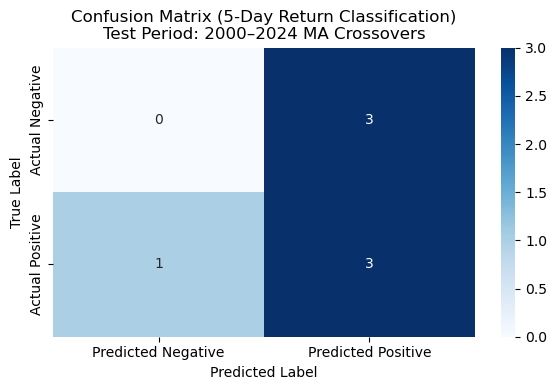


RQ3: Correlation between MSFT and QQQ returns: 0.8554


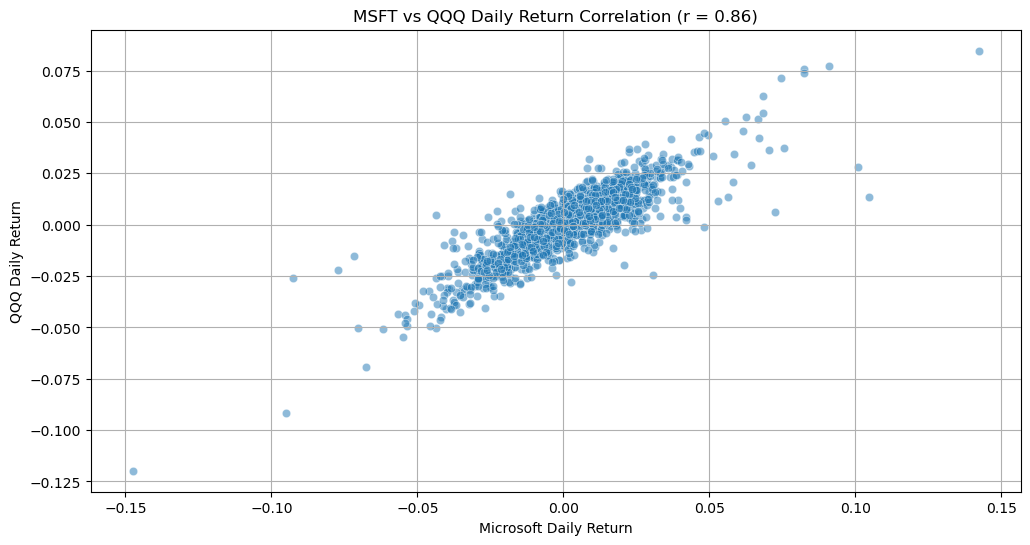


MSFT vs QQQ Return Correlation (OLS Regression)
                            OLS Regression Results                            
Dep. Variable:      daily_return_msft   R-squared:                       0.732
Model:                            OLS   Adj. R-squared:                  0.732
Method:                 Least Squares   F-statistic:                     6855.
Date:                Sun, 08 Jun 2025   Prob (F-statistic):               0.00
Time:                        22:35:22   Log-Likelihood:                 8326.3
No. Observations:                2515   AIC:                        -1.665e+04
Df Residuals:                    2513   BIC:                        -1.664e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------

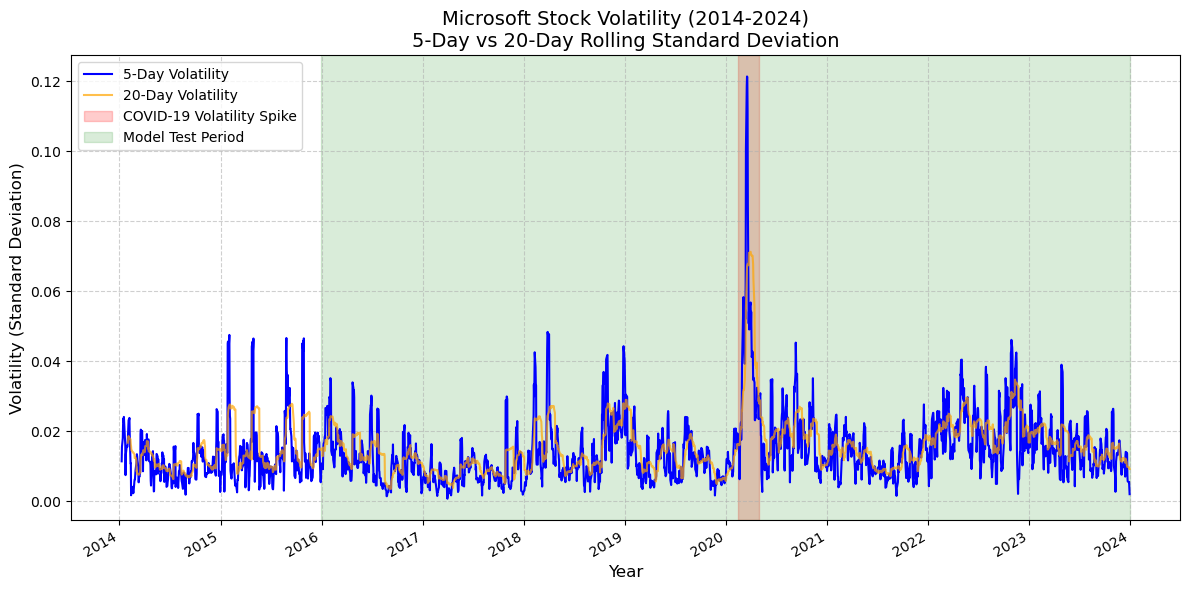


RQ4 Hypothesis Test Results (1986-2024)
Model Accuracy: 0.4968
Z-statistic: -0.2752, p-value: 0.6084
RQ4: FAIL TO REJECT H₀: No evidence of predictive power above random chance

Top Predictive Features:
volatility_20d    0.093568
return_lag_2      0.093520
daily_return      0.092802
return_lag_3      0.092580
return_lag_1      0.092275
rsi_lag_2         0.092227
volatility_5d     0.090824
rsi_lag_1         0.090437
rsi               0.089774
macd              0.087495
dtype: float64


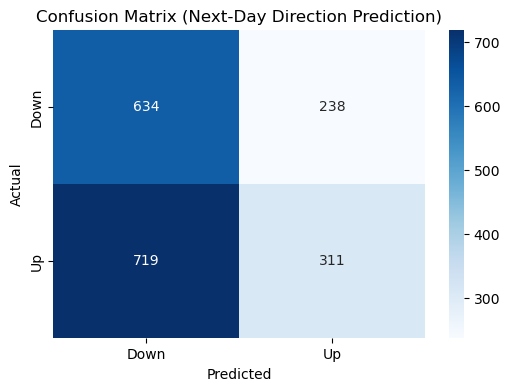

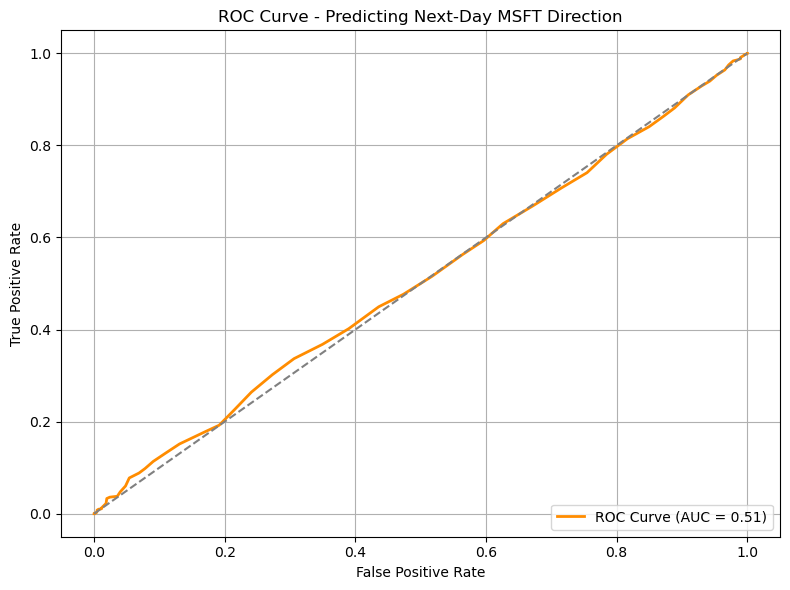

In [115]:
#DRAFT
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import scipy.stats as stats
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from statsmodels.stats.proportion import proportions_ztest

# ---------------------------------------------
# 1. Load and Clean Microsoft Stock Data (MSFT)
# ---------------------------------------------

# Load the dataset
msft = pd.read_csv('MSFT.csv')

# Standardize column names
msft.columns = msft.columns.str.strip().str.lower()

# Convert 'date' to datetime and set as index
msft['date'] = pd.to_datetime(msft['date'], errors='coerce')
msft.set_index('date', inplace=True)
msft.sort_index(inplace=True)

# Check and drop rows with missing values in key columns
msft = msft.dropna(subset=['close'])

# Remove any duplicate entries
msft = msft[~msft.index.duplicated(keep='first')]

# Create two datasets: recent (2014-2024) and full (1986-2024)
msft_recent = msft.loc['2014-01-01':'2024-01-01'].copy()
msft_full = msft.loc['1986-01-01':'2024-01-01'].copy()

# ---------------------------------------------
# 2. Feature Engineering - Recent Data (for RQ1-RQ3)
# ---------------------------------------------

# Daily return calculation
msft_recent['daily_return'] = msft_recent['close'].pct_change()

# Rolling volatility
msft_recent['volatility_5d'] = msft_recent['daily_return'].rolling(window=5).std()
msft_recent['volatility_20d'] = msft_recent['daily_return'].rolling(window=20).std()

# Calendar features (for RQ1)
msft_recent['month'] = msft_recent.index.month
msft_recent['year'] = msft_recent.index.year
msft_recent['weekday'] = msft_recent.index.dayofweek

# Moving averages and crossover (for RQ2)
msft_recent['ma50'] = msft_recent['close'].rolling(window=50).mean()
msft_recent['ma200'] = msft_recent['close'].rolling(window=200).mean()
msft_recent['crossover'] = (msft_recent['ma50'] > msft_recent['ma200']).astype(int)
msft_recent['next_day_return'] = msft_recent['close'].shift(-1) / msft_recent['close'] - 1
msft_recent['crossover_signal'] = msft_recent['crossover'].diff()

# Multi-day returns (for RQ2 extended)
msft_recent['return_3d'] = msft_recent['close'].shift(-3) / msft_recent['close'] - 1
msft_recent['return_5d'] = msft_recent['close'].shift(-5) / msft_recent['close'] - 1
msft_recent['return_10d'] = msft_recent['close'].shift(-10) / msft_recent['close'] - 1

# ---------------------------------------------
# 3. Feature Engineering - Full Data (for RQ4)
# ---------------------------------------------

# For RQ4 prediction only
msft_full['daily_return'] = msft_full['close'].pct_change()

# RSI calculation
delta = msft_full['close'].diff()
gain = delta.where(delta > 0, 0)
loss = -delta.where(delta < 0, 0)
avg_gain = gain.rolling(window=14).mean()
avg_loss = loss.rolling(window=14).mean()
rs = avg_gain / avg_loss
msft_full['rsi'] = 100 - (100 / (1 + rs))

# MACD calculation
exp12 = msft_full['close'].ewm(span=12, adjust=False).mean()
exp26 = msft_full['close'].ewm(span=26, adjust=False).mean()
msft_full['macd'] = exp12 - exp26
msft_full['signal_line'] = msft_full['macd'].ewm(span=9, adjust=False).mean()

# Volatility measures
msft_full['volatility_5d'] = msft_full['daily_return'].rolling(window=5).std()
msft_full['volatility_20d'] = msft_full['daily_return'].rolling(window=20).std()

# Target variable (next day's price direction)
msft_full['target'] = (msft_full['close'].shift(-1) > msft_full['close']).astype(int)

# Lagged features
for lag in [1, 2, 3, 5]:
    msft_full[f'return_lag_{lag}'] = msft_full['daily_return'].shift(lag)
    msft_full[f'rsi_lag_{lag}'] = msft_full['rsi'].shift(lag)

msft_full = msft_full.dropna()

# ---------------------------------------------
# 3. Descriptive Statistics (Data Understanding)
# ---------------------------------------------

# Summary statistics
print("Descriptive statistics for closing price:")
print(msft_recent['close'].describe())

print("\nDescriptive statistics for daily return:")
print(msft_recent['daily_return'].describe())

# Standard deviation and variance
print(f"\nStandard deviation: {msft_recent['daily_return'].std():.6f}")
print(f"Variance: {msft_recent['daily_return'].var():.6f}")

# Skewness and kurtosis
print(f"Skewness: {msft_recent['daily_return'].skew():.4f}")
print(f"Kurtosis: {msft_recent['daily_return'].kurtosis():.4f}")

# Outlier detection using IQR
Q1 = msft_recent['daily_return'].quantile(0.25)
Q3 = msft_recent['daily_return'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers = msft_recent[(msft_recent['daily_return'] < lower) | (msft_recent['daily_return'] > upper)]
print(f"\nOutlier bounds: {lower:.4f} to {upper:.4f}")
print(f"Number of outliers: {len(outliers)}")

# ---------------------------------------------
# RQ1: Monthly Return Seasonality (ANOVA)
# ---------------------------------------------
print("\nRQ1: Monthly Return Seasonality")

# Monthly Return Boxplot
plt.figure(figsize=(12, 6))
sns.boxplot(x='month', y='daily_return', data=msft_recent)
plt.title('Monthly Distribution of Microsoft Daily Returns (2014–2024)')
plt.xlabel('Month')
plt.ylabel('Daily Return')
plt.grid(True)
plt.show()

anova_model = sm.OLS.from_formula('daily_return ~ C(month)', data=msft_recent.dropna()).fit()
anova_table = sm.stats.anova_lm(anova_model, typ=2)
#print(anova_table)
print(anova_model.summary())

f_stat = anova_table['F'].iloc[0]
p_val = anova_table['PR(>F)'].iloc[0]

print(f"\nANOVA F-statistic: {f_stat:.4f}, p-value: {p_val:.4f}")
if p_val < 0.05:
    print("RQ1: REJECT H₀: There is a significant monthly effect on stock returns.")
else:
    print("RQ1: FAIL TO REJECT H₀: No significant difference in returns across months.")


# ---------------------------------------------
# RQ2: Return Following MA Crossovers (t-test)
# ---------------------------------------------
print("\nRQ2: Return Following MA Crossovers")
bullish = msft_recent[msft_recent['crossover_signal'] == 1]['next_day_return']
bearish = msft_recent[msft_recent['crossover_signal'] == -1]['next_day_return']
t_stat, p_val = stats.ttest_ind(bullish.dropna(), bearish.dropna(), equal_var=False)
print(f"Bullish Mean: {bullish.mean():.5f}, Bearish Mean: {bearish.mean():.5f}")
print(f"t-statistic: {t_stat:.4f}, p-value: {p_val:.4f}")
print("Conclusion:", "Reject H₀" if p_val < 0.05 else "Fail to Reject H₀")

# Moving Average Crossover Line Plot (Focused on 2022–2024)
msft_focus = msft_recent.loc['2022-01-01':'2024-01-01']
crossover_points = msft_focus[msft_focus['crossover'].diff() != 0]


plt.figure(figsize=(12, 6))
plt.plot(msft_focus['close'], label='Close Price', alpha=0.6)
plt.plot(msft_focus['ma50'], label='50-Day MA', linestyle='--')
plt.plot(msft_focus['ma200'], label='200-Day MA', linestyle='--')

# Track if we've added each type of crossover to the legend
bullish_shown = False
bearish_shown = False

# Plot crossover lines with conditional labeling
for date in crossover_points.index:
    signal = msft_focus.loc[date, 'crossover']
    if signal == 1:
        plt.axvline(x=date, color='purple', linestyle=':', alpha=0.9,
                    label='Bullish Crossover' if not bullish_shown else "")
        bullish_shown = True
    else:
        plt.axvline(x=date, color='red', linestyle=':', alpha=0.9,
                    label='Bearish Crossover' if not bearish_shown else "")
        bearish_shown = True

plt.title('MSFT Close Price with Moving Averages (2022–2024)')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

# ---------------------------------------------
# RQ2 (Extended): Multi-Day Return Analysis After MA Crossover
# ---------------------------------------------
print("\nRQ2 Extended: Multi-Day Return Evaluation After MA Crossovers")

# Reuse msft_recent (2014–2024) or expand if needed
msft_recent['return_3d'] = msft_recent['close'].shift(-3) / msft_recent['close'] - 1
msft_recent['return_5d'] = msft_recent['close'].shift(-5) / msft_recent['close'] - 1
msft_recent['return_10d'] = msft_recent['close'].shift(-10) / msft_recent['close'] - 1

# Filter crossover points
bullish_idx = msft_recent[msft_recent['crossover_signal'] == 1].index
bearish_idx = msft_recent[msft_recent['crossover_signal'] == -1].index

# Compare 3-day, 5-day, 10-day returns
for horizon in ['return_3d', 'return_5d', 'return_10d']:
    bullish_returns = msft_recent.loc[bullish_idx, horizon].dropna()
    bearish_returns = msft_recent.loc[bearish_idx, horizon].dropna()
    
    t_stat, p_val = stats.ttest_ind(bullish_returns, bearish_returns, equal_var=False)
    print(f"\n* {horizon.upper()} Comparison")
    print(f"  Bullish Mean: {bullish_returns.mean():.4f}, Bearish Mean: {bearish_returns.mean():.4f}")
    print(f"  t-statistic: {t_stat:.4f}, p-value: {p_val:.4f}")
    if p_val < 0.05:
        print("RQ2: Significant difference in returns between bullish and bearish crossovers")
    else:
        print("RQ3: No significant difference — crossovers not statistically predictive at this horizon")

# Optional visual comparison (boxplot)

# Prepare melted DataFrames per return horizon
returns_3d = pd.concat([
    msft_recent.loc[bullish_idx, 'return_3d'].dropna().rename('Bullish'),
    msft_recent.loc[bearish_idx, 'return_3d'].dropna().rename('Bearish')
], axis=1).reset_index(drop=True).melt(var_name='Crossover Type', value_name='Return')
returns_3d['Horizon'] = '3-Day'

returns_5d = pd.concat([
    msft_recent.loc[bullish_idx, 'return_5d'].dropna().rename('Bullish'),
    msft_recent.loc[bearish_idx, 'return_5d'].dropna().rename('Bearish')
], axis=1).reset_index(drop=True).melt(var_name='Crossover Type', value_name='Return')
returns_5d['Horizon'] = '5-Day'

returns_10d = pd.concat([
    msft_recent.loc[bullish_idx, 'return_10d'].dropna().rename('Bullish'),
    msft_recent.loc[bearish_idx, 'return_10d'].dropna().rename('Bearish')
], axis=1).reset_index(drop=True).melt(var_name='Crossover Type', value_name='Return')
returns_10d['Horizon'] = '10-Day'

# Combine all horizons
plot_data = pd.concat([returns_3d, returns_5d, returns_10d], ignore_index=True)

# Plot using seaborn
plt.figure(figsize=(12, 6))
sns.boxplot(data=plot_data, x='Horizon', y='Return', hue='Crossover Type')
plt.title(" Multi-Day Returns After Bullish vs Bearish MA Crossovers")
plt.grid(True)
plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.show()

# ---------------------------------------------
# RQ2 Extended: Regression and Classification on Post-Crossover Returns
# ---------------------------------------------
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_squared_error, accuracy_score, roc_auc_score,
    classification_report, confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("\nRQ2 Extended: Predictive Modeling of Returns After MA Crossovers")

# 1. Filter msft_full for 2000–2024
crossover_data = msft_full.loc['2000-01-01':'2024-01-01'].copy()

# 2. Add Moving Averages and Crossover Signal
crossover_data['ma50'] = crossover_data['close'].rolling(window=50).mean()
crossover_data['ma200'] = crossover_data['close'].rolling(window=200).mean()
crossover_data['crossover'] = (crossover_data['ma50'] > crossover_data['ma200']).astype(int)
crossover_data['crossover_signal'] = crossover_data['crossover'].diff()

# 3. Calculate 5-day future return
crossover_data['return_5d'] = crossover_data['close'].shift(-5) / crossover_data['close'] - 1

# 4. Filter only crossover signals (bullish or bearish) and drop NA
crossover_data = crossover_data[crossover_data['crossover_signal'].isin([1, -1])]
crossover_data = crossover_data.dropna(subset=[
    'return_5d', 'daily_return', 'volatility_5d', 'volatility_20d',
    'rsi', 'macd', 'signal_line'
])

# 5. Define features and target variables
features = ['daily_return', 'volatility_5d', 'volatility_20d', 'rsi', 'macd', 'signal_line']
X = crossover_data[features]
y_regression = crossover_data['return_5d']
y_classification = (crossover_data['return_5d'] > 0).astype(int)

# 6. Train-Test Split (80-20)
X_train, X_test, y_train_reg, y_test_reg = train_test_split(X, y_regression, test_size=0.2, random_state=42, shuffle=True)
_, _, y_train_cls, y_test_cls = train_test_split(X, y_classification, test_size=0.2, random_state=42, shuffle=True)

# ---------------------------------------------
# A. Linear Regression: Predict actual 5-day return
# ---------------------------------------------
reg_model = LinearRegression()
reg_model.fit(X_train, y_train_reg)
y_pred_reg = reg_model.predict(X_test)

mse = mean_squared_error(y_test_reg, y_pred_reg)
r2 = reg_model.score(X_test, y_test_reg)

print("\nLinear Regression Results (Predicting 5-Day Return)")
print(f"R² Score: {r2:.4f}")
print(f"Mean Squared Error: {mse:.6f}")

# Coefficients
reg_coef = pd.Series(reg_model.coef_, index=features)
print("\nTop Predictive Features (Linear Regression):")
print(reg_coef.sort_values(ascending=False))

# Residual Plot
residuals = y_test_reg - y_pred_reg
plt.figure(figsize=(10, 5))
sns.scatterplot(x=y_pred_reg, y=residuals, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.title("Linear Regression Residual Plot\n(Test Period: 2000–2024 MA Crossovers)")
plt.xlabel("Predicted 5-Day Return")
plt.ylabel("Residuals")
plt.grid(True)
plt.show()

# ---------------------------------------------
# B. Logistic Regression: Classify return > 0
# ---------------------------------------------
clf_model = LogisticRegression(max_iter=1000)
clf_model.fit(X_train, y_train_cls)
y_pred_cls = clf_model.predict(X_test)
y_prob_cls = clf_model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test_cls, y_pred_cls)
roc_auc = roc_auc_score(y_test_cls, y_prob_cls)

print("\nLogistic Regression Results (Classify 5-Day Return > 0)")
print(f"Accuracy: {accuracy:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_cls, y_pred_cls, target_names=["Negative", "Positive"]))

# Coefficients
clf_coef = pd.Series(clf_model.coef_[0], index=features)
print("\nTop Predictive Features (Logistic Regression):")
print(clf_coef.sort_values(ascending=False))

# Confusion Matrix
cm = confusion_matrix(y_test_cls, y_pred_cls)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Predicted Negative", "Predicted Positive"],
            yticklabels=["Actual Negative", "Actual Positive"])
plt.title("Confusion Matrix (5-Day Return Classification)\nTest Period: 2000–2024 MA Crossovers")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()



# ---------------------------------------------
# RQ3: MSFT vs QQQ Correlation (OLS)
# ---------------------------------------------

#Load QQQ and Compute Correlation
qqq = pd.read_csv('QQQ.csv')
qqq.columns = qqq.columns.str.strip().str.lower()
qqq['date'] = pd.to_datetime(qqq['date'], errors='coerce')
qqq.set_index('date', inplace=True)
qqq = qqq.dropna(subset=['close'])
qqq.sort_index(inplace=True)
qqq = qqq.loc['2014-01-01':'2024-01-01']
qqq['daily_return'] = qqq['close'].pct_change()

# Correlation
merged_returns = pd.merge(
    msft_recent[['daily_return']], qqq[['daily_return']],
    left_index=True, right_index=True, suffixes=('_msft', '_qqq')).dropna()

correlation = merged_returns.corr().iloc[0, 1]
print(f"\nRQ3: Correlation between MSFT and QQQ returns: {correlation:.4f}")

# MSFT vs QQQ Correlation Scatter Plot
plt.figure(figsize=(12, 6))
sns.scatterplot(x='daily_return_msft', y='daily_return_qqq', data=merged_returns, alpha=0.5)
plt.title(f'MSFT vs QQQ Daily Return Correlation (r = {correlation:.2f})')
plt.xlabel('Microsoft Daily Return')
plt.ylabel('QQQ Daily Return')
plt.grid(True)
plt.show()
#

print("\nMSFT vs QQQ Return Correlation (OLS Regression)")
X = sm.add_constant(merged_returns['daily_return_qqq'])
y = merged_returns['daily_return_msft']
model = sm.OLS(y, X).fit()
print(model.summary())


# ---------------------------------------------
# RQ4: Predictive Modeling with Random Forest
# ---------------------------------------------
print("\nRQ4: Predict Next-Day MSFT Direction")

# Volatility Over Time - Context for Predictive Modeling (2014-2024 only)
plt.figure(figsize=(12, 6))

# Plot 5-day and 20-day volatility
msft_recent['volatility_5d'].dropna().plot(label='5-Day Volatility', color='blue', linewidth=1.5)
msft_recent['volatility_20d'].dropna().plot(label='20-Day Volatility', color='orange', alpha=0.7, linewidth=1.5)

# COVID-19 market crash
plt.axvspan(pd.to_datetime('2020-02-15'), pd.to_datetime('2020-04-30'), 
            color='red', alpha=0.2, label='COVID-19 Volatility Spike')

# Fix: Define test period using dates
test_start_date = msft_recent.index[int(0.2 * len(msft_recent))]
test_end_date = msft_recent.index[-1]
plt.axvspan(test_start_date, test_end_date, color='green', alpha=0.15, label='Model Test Period')

# Final touches
plt.title('Microsoft Stock Volatility (2014-2024)\n5-Day vs 20-Day Rolling Standard Deviation', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Volatility (Standard Deviation)', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()



# Features already prepared in the full dataset feature engineering section
rq4_features = ['daily_return', 'volatility_5d', 'volatility_20d', 
               'rsi', 'macd', 'signal_line', 
               'return_lag_1', 'return_lag_2', 'return_lag_3',
               'rsi_lag_1', 'rsi_lag_2']
X_rq4 = msft_full[rq4_features]
y_rq4 = msft_full['target']

# Train-test split (80-20)
X_train_rq4, X_test_rq4, y_train_rq4, y_test_rq4 = train_test_split(
    X_rq4, y_rq4, test_size=0.2, shuffle=False, random_state=42)

# Train Random Forest model
model_rq4 = RandomForestClassifier(n_estimators=100, random_state=42)
model_rq4.fit(X_train_rq4, y_train_rq4)

# Make predictions
y_pred_rq4 = model_rq4.predict(X_test_rq4)
accuracy_rq4 = accuracy_score(y_test_rq4, y_pred_rq4)

# Statistical test against 50% baseline
n_success_rq4 = sum(y_pred_rq4 == y_test_rq4)
n_total_rq4 = len(y_test_rq4)
z_stat_rq4, p_value_rq4 = proportions_ztest(n_success_rq4, n_total_rq4, value=0.5, alternative='larger')

# Get feature importance
importance_rq4 = pd.Series(model_rq4.feature_importances_, index=rq4_features).sort_values(ascending=False)

# Print results
print(f"\nRQ4 Hypothesis Test Results (1986-2024)")
print(f"Model Accuracy: {accuracy_rq4:.4f}")
print(f"Z-statistic: {z_stat_rq4:.4f}, p-value: {p_value_rq4:.4f}")

if accuracy_rq4 > 0.55 and p_value_rq4 < 0.05:
    print("RQ4: REJECT H₀: Technical indicators provide statistically significant predictive power (>55% accuracy)")
else:
    print("RQ4: FAIL TO REJECT H₀: No evidence of predictive power above random chance")

print("\nTop Predictive Features:")
print(importance_rq4.head(10))

# Confusion matrix visualization
cm_rq4 = confusion_matrix(y_test_rq4, y_pred_rq4)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_rq4, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Down', 'Up'], yticklabels=['Down', 'Up'])
plt.title('Confusion Matrix (Next-Day Direction Prediction)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# ---------------------------------------------
# RQ4: ROC Curve for Model Evaluation
# ---------------------------------------------
from sklearn.metrics import roc_curve, auc

# Predicted probabilities for positive class
y_prob_rq4 = model_rq4.predict_proba(X_test_rq4)[:, 1]

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test_rq4, y_prob_rq4)
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f"ROC Curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.title("ROC Curve - Predicting Next-Day MSFT Direction")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()